In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from compartments import SEIR_patch_get_trajectory, CompartmentPatchArray
import matplotlib.animation as animation
import glob


In [2]:
def combine_mobility_agerates(mobility_matrix: np.ndarray, age_rate_matrix: np.ndarray):
    shape = [mobility_matrix.shape[0] * age_rate_matrix.shape[0]] * 2
    network_matrix = np.zeros(shape=shape)
    num_ages = age_rate_matrix.shape[0]
    for i, mobility in enumerate(mobility_matrix):
        for j, mjtoi in enumerate(mobility):
            slice1i, slice1e = i * num_ages, (i + 1) * num_ages
            slice2i, slice2e = j * num_ages, (j + 1) * num_ages
            network_matrix[slice1i:slice1e, slice2i:slice2e] = mjtoi * age_rate_matrix
    return network_matrix

def get_patch_basebetas_from_unit_betas(betas_units: np.ndarray, num_age_groups: int):
    return np.repeat(betas_units, num_age_groups)



# I asked gemini to create a wrapper function based on the functions I had already written
def run_packaged_simulation(
    unit_mobility_matrix,
    age_contact_matrix,
    initial_state_units_ages,
    betas_units,
    steps=200,
    alpha=1/5.8,
    gamma=1/5.0,
    vaccination_daily_rate_units=None,
    vaccine_efficacy=0.8,
    waning_weibull_shape=3.7,
    waning_weibull_scale=120
):
    NUM_UNITS = unit_mobility_matrix.shape[0]
    NUM_AGES = age_contact_matrix.shape[0]
    NUM_PATCHES = NUM_UNITS * NUM_AGES

    # 1. Combine Matrices
    network_matrix = combine_mobility_agerates(unit_mobility_matrix, age_contact_matrix)
    
    # 2. Flatten Initial States and Betas
    initial_state = initial_state_units_ages.reshape((NUM_PATCHES, 5))
    betas_patches = get_patch_basebetas_from_unit_betas(betas_units, NUM_AGES)
    
    # 3. Handle Daily Vaccination (Distribute equally across age groups)
    if vaccination_daily_rate_units is None:
        vaccination_daily_rate_units = np.zeros(NUM_UNITS)
    
    # Divide unit vaccines among age groups 
    vaccine_per_patch = np.repeat(vaccination_daily_rate_units / NUM_AGES, NUM_AGES)
   
    # Create the schedule and apply the 14-day lag automatically
    vaccination_schedule = np.tile(vaccine_per_patch, (steps, 1))
    vaccination_14_days_prior_list = np.zeros_like(vaccination_schedule)
    if steps > 14:
        vaccination_14_days_prior_list[14:] = vaccination_schedule[:-14]

    # 4. Initialize and Run
    patch_array = CompartmentPatchArray(
        state=np.copy(initial_state),
        num_patches=NUM_PATCHES,
        num_compartments=5,
        iter_num=0
    )
    
    trajectory = SEIR_patch_get_trajectory(
        STEPS=steps,
        compartment_patch_array=patch_array,
        vaccination_14_days_prior_list=vaccination_14_days_prior_list,
        vaccine_efficacy=vaccine_efficacy,
        betas_patches=betas_patches,
        alpha=alpha,
        gamma=gamma,
        network_matrix=network_matrix,
        waning_weibull_shape=waning_weibull_shape,
        waning_weibull_scale=waning_weibull_scale
    )
    
    # 5. Reshape back to human-readable dimensions (Time, Units, Ages, Compartments)
    return np.array(trajectory).reshape((steps + 1, NUM_UNITS, NUM_AGES, 5))



['BAGALKOTE', 'BENGALURU URBAN', 'BENGALURU RURAL', 'BELAGAVI', 'BALLARI', 'BIDAR', 'VIJAYAPURA', 'CHAMARAJANAGARA', 'CHIKKAMAGALURU', 'CHITRADURGA', 'DAKSHINA KANNADA', 'DAVANGERE', 'DHARWAD', 'GADAG', 'KALABURAGI', 'HASSAN', 'HAVERI', 'KODAGU', 'KOLAR', 'KOPPAL', 'MANDYA', 'MYSURU', 'RAICHUR', 'SHIVAMOGGA', 'TUMAKURU', 'UDUPI', 'UTTARA KANNADA', 'CHIKKABALLAPURA', 'RAMANAGARA', 'YADGIR', 'VIJAYANAGAR']
Seed Index 1
Seed Index 1


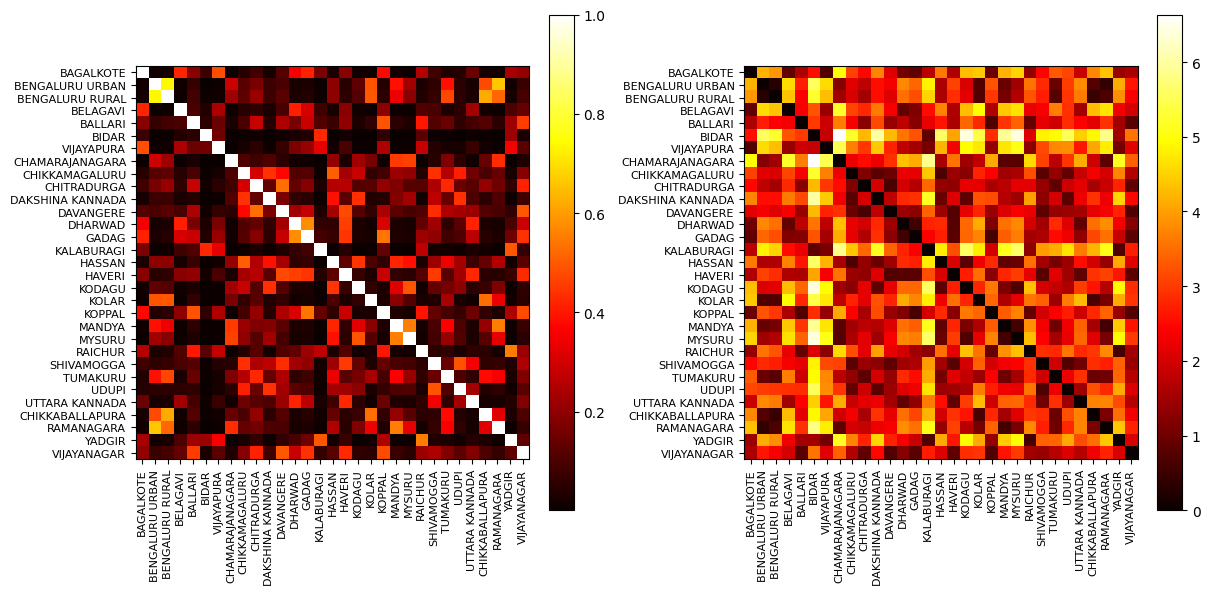

In [ ]:
ALPHA = 1/5.8
GAMMA = 1/5
WANING_SHAPE = 0
WANING_SCALE = 0



gdf = gpd.read_file('karnataka-data/karnataka_districts.geojson')
gdf['centroid'] = gdf.to_crs(epsg=32643).geometry.centroid
UNITS = gdf['name'].tolist()
NUM_UNITS = len(UNITS)

UNIT_MOBILITY = np.zeros((NUM_UNITS, NUM_UNITS))
DISTANCES = np.zeros((NUM_UNITS, NUM_UNITS))
coords = [(c.x, c.y) for c in gdf['centroid']] 
for i in range(NUM_UNITS):
    for j in range(NUM_UNITS):
        # Distance in meters (scaled down by 100km to avoid exp(-huge) = 0)
        dist_scaled = np.sqrt((coords[j][0] - coords[i][0])**2 + (coords[j][1] - coords[i][1])**2) / 100000.0
        UNIT_MOBILITY[i, j] = np.exp(-dist_scaled)
        DISTANCES[i, j] = dist_scaled

# 3. Set up Age Groups
NUM_AGES = 4
age_groups  = []
delta = 80/NUM_AGES
for i in range(NUM_AGES):
    age_groups.append(f'Ages {i*delta}-{(i+1)*delta}')

AGE_CONTACT_MATRIX = np.eye(NUM_AGES) # Add cross-mixing here later
# 4. Initial State: (Units, Ages, Compartments)
# Compartments: [S, E, I, R, V]
initial_state_matrix = np.zeros((NUM_UNITS, NUM_AGES, 5))
initial_state_matrix[:, :, 0] = 10000 # 10k Susceptibles everywhere for every age group

print(UNITS)
# Bangalore as epicenter with
## Changing the unit mobility to have only two states interact
blr_idx = UNITS.index('BENGALURU URBAN')
blr_r_idx = list()
# blr_idx = UNITS.index('BENGALURU URBAN')

# UNIT_MOBILITY = np.zeros((NUM_UNITS, NUM_UNITS))
# blr_r_idx.append(UNITS.index('CHIKKAMAGALURU'))
# blr_r_idx.append(UNITS.index('BENGALURU RURAL'))
# for rind in blr_r_idx:
#     UNIT_MOBILITY[rind, blr_idx] =1

print(f'Seed Index {blr_idx}')

SEEDAGEGROUPNO = 2
# UNIT_MOBILITY[blr_idx, blr_r_idx] =1
# Seed 1000 infected in Bengaluru, Age Group 2 (20-40yo)
initial_state_matrix[blr_idx, SEEDAGEGROUPNO, 2] = 1000

# Uniform beta across all units
betas = np.ones(NUM_UNITS) #* 0.25
print(f'Seed Index {blr_idx}')




DIFFUSION_UNIT_MOBILITY = np.ones((NUM_UNITS, NUM_UNITS))/NUM_UNITS
DIFFUSION_AGE_RATES = np.ones((NUM_AGES, NUM_AGES))

mobility = UNIT_MOBILITY# DIFFUSION_UNIT_MOBILITY
# mobility = DIFFUSION_UNIT_MOBILITY
age_rate = AGE_CONTACT_MATRIX #DIFFUSION_AGE_RATES
# age_rate = DIFFUSION_AGE_RATES
# Run


fig, axs = plt.subplots(1 ,2 , constrained_layout = True, figsize = (12, 10) )
m = axs[0].imshow(UNIT_MOBILITY, cmap ='hot')
plt.colorbar(mappable= m, ax=axs[0], shrink = 0.5)
m = axs[1].imshow(DISTANCES, cmap ='hot')

indices = np.arange(len(UNITS))
axs[0].set_xticks(indices)
axs[1].set_xticks(indices)

axs[0].set_yticks(indices)
axs[1].set_yticks(indices)

axs[0].set_xticklabels(UNITS, rotation=90, fontsize=8, ha='center')
axs[0].set_yticklabels(UNITS, fontsize=8)
axs[1].set_xticklabels(UNITS, rotation=90, fontsize=8, ha='center')
axs[1].set_yticklabels(UNITS, fontsize=8)
# ax.xaxis.tick_top() # Moves ticks and labels to top
# ax.xaxis.set_label_position('top')

plt.colorbar(mappable= m, ax=axs[1], shrink = 0.5)
# plt.savefig('outputs/Distances.png')

In [4]:
traj = run_packaged_simulation(
    mobility,
    age_rate,
    initial_state_matrix,
    betas,
    steps=150,
    waning_weibull_scale=WANING_SCALE,
    waning_weibull_shape=WANING_SHAPE
)



## Visualisation of the spread

In [ ]:
## yeah this all was done with gemini, i don't know any geojson visualisation


# 1. Extract the specific data we want to animate
# traj shape is (Time, Units, Ages, Compartments)
# We want Compartment 2 (Infected), summed across all Age Groups (axis 2)
# Resulting shape: (151 frames, 31 units)
infected_trajectory = traj[:, :, :, 2].sum(axis=2)

# 2. Find the global maximum to lock the color scale
# If you don't do this, the colors will flash wildly as the max changes every frame
vmax_infected = infected_trajectory.max()

# 3. Setup the Figure and the base map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_title("Infection Spread Over Time", fontsize=16)
ax.axis('off')

# Plot the initial frame (Time = 0)
# We add this data temporarily to the GeoDataFrame just to initialize the plot
gdf['current_infected'] = infected_trajectory[0]

# Create the map plot. We capture the returned collection object
colormap = plt.cm.RdYlBu_r
map_plot = gdf.plot(
    column='current_infected',
    ax=ax, 
    cmap=colormap,
    vmin=0, 
    vmax=vmax_infected,     # Locked color scale
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': "Total Infected", 'shrink': 0.5}
)

# Extract the polygon collection so we can update its colors later
# (geopandas plot returns an axes, but we need the actual shape collection)




# --- NEW: ADD DISTRICT LABELS ---
# We calculate centroids once. 'representative_point' is safer than 'centroid' 
# because it's guaranteed to be inside the polygon (important for C-shaped districts).
gdf['coords'] = gdf['geometry'].apply(lambda x: x.representative_point().coords[:])
gdf['coords'] = [coords[0] for coords in gdf['coords']]

for idx, row in gdf.iterrows():
    # You can wrap this in an 'if' statement to only label specific districts
    ax.text(
        s=row['name'], # Ensure this matches your GeoJSON column name
        x=row['coords'][0], 
        y=row['coords'][1],
        horizontalalignment='center',
        fontsize=7,
        fontweight='bold',
        alpha=0.6,      # Slightly transparent so it doesn't block the color
        color='black'
    )
# Hacky solution that differs from gemini's solution
# Create one more named column in the dataframe in this and just update it
gdf['Infections'] = infected_trajectory[0]
# 4. Define the update function for the animation
def update_map(frame):
    # Grab the infected numbers for this specific timestep
    current_data = infected_trajectory[frame]
    gdf['Infections'] = current_data
    # Update the color values of the polygons
    p = gdf.plot(column='Infections', ax = ax, cmap=colormap)
    # Update the title with the current day
    ax.set_title(f"Karnataka Infection Spread - Day {frame}"\
                    "\n Diffusive interactions ", fontsize=16)
    
    return p

# 5. Create the Animation
ani = animation.FuncAnimation(
    fig,
    update_map,
    frames=len(infected_trajectory),
    blit=False
)

# num = len(glob.glob('outputs/set-*.npz'))
# np.savez(f'outputs/set-{num+1}.npz')
# ani.save('outputs/karnataka_spread_blr_epicenter_diffusive_nowaning.gif', fps=10)

MovieWriter ffmpeg unavailable; using Pillow instead.


In [ ]:
ani

In [ ]:
## Looking at the seed patch




## Age distribution animation

In [ ]:
fig, ax = plt.subplots()
ax.set_ylim(0, 1) # Lock the Y-axis so it doesn't jump

# 2. Create the Initial Bars
UNITNAME = 'BENGALURU URBAN'
idx = UNITS.index(UNITNAME)
bardata = traj[:,idx, :, 2]/traj[:,idx, :].sum(axis = -1)
# We store the 'container' which holds the individual bar rectangles
bar_container = ax.bar(age_groups, bardata[0], color='skyblue')
print(bardata[0])
# 3. The Update Function
def update(frame):
    # Grab the data slice for this frame
    current_heights = bardata[frame]
    
    # Update each rectangle in the container
    for rect, h in zip(bar_container, current_heights):

        rect.set_height(h)
    ax.set_title(f'Fraction of Infections Unit: {UNITNAME} Day: {frame} ')
    return bar_container

# 4. Create the Animation
ani = animation.FuncAnimation(fig, update, frames=bardata.shape[0], interval=50, blit=True)
ani.save('outputs/karnataka_spread_blr_epicenter_age_dist_nodiffageinteraction.gif', fps=10)

plt.show()